# Diabetic 130 Dataset – Exploratory Data Analysis (EDA)

Focus:
- Feature distributions
- Missing (null) values



## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

real_path = 'Real_Datasets/diabetic_data.csv'
df = pd.read_csv(real_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## 3. Missing Values

In [3]:
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_abs,
    'missing_percent': missing_pct
})

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()

missing_percentage = (total_missing / total_cells) * 100
print("total missing values:", missing_percentage)

missing_df[missing_df.missing_count > 0].head(20)

total missing values: 3.5604818898256783


,missing_count,missing_percent
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322


## 4. Missing Values Plot

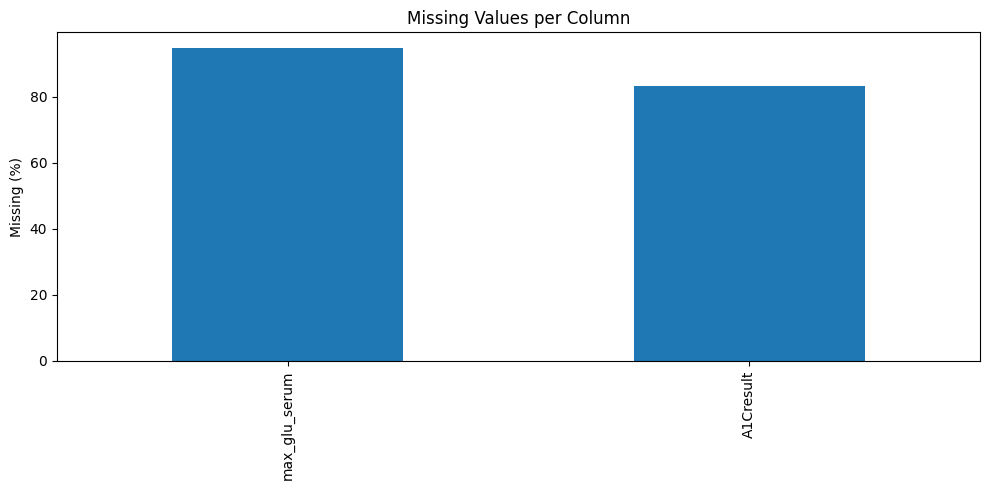

In [4]:
plt.figure(figsize=(10,5))
missing_pct[missing_pct > 0].plot(kind='bar')
plt.ylabel('Missing (%)')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

In [5]:
df_filtered = df[df.notna().sum(axis=1) >= 10]
print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

print("Rows removed:", df.shape[0] - df_filtered.shape[0])

x = 30  # threshold in percent

missing_pct = df_filtered.isna().mean() * 100
df_filtered2 = df_filtered.loc[:, missing_pct <= x]

removed = set(df_filtered.columns) - set(df_filtered2.columns)
print("Dropped columns:", removed)

print("Filtered2 shape:", df_filtered2.shape)
#df_filtered2.to_csv('Real_Datasets/diabetic_data_cleaned.csv',index=False)

Original shape: (101766, 50)
Filtered shape: (101766, 50)
Rows removed: 0
Dropped columns: {'max_glu_serum', 'A1Cresult'}
Filtered2 shape: (101766, 48)


## 5. Numeric Distributions

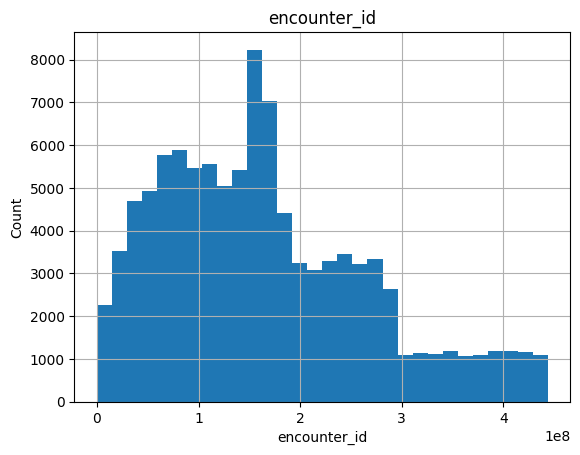

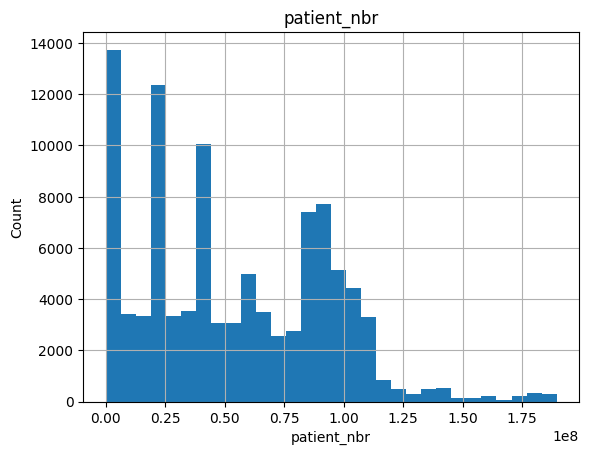

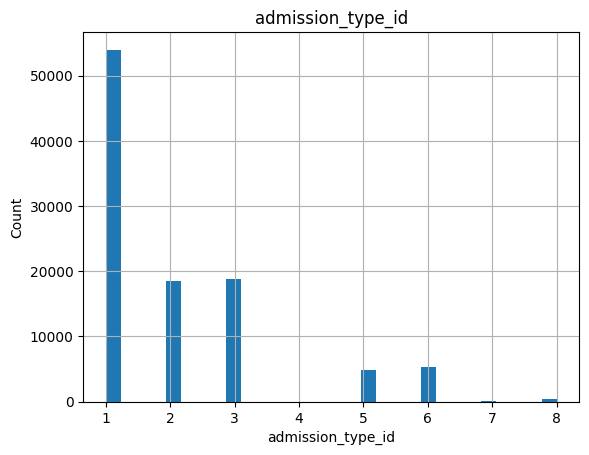

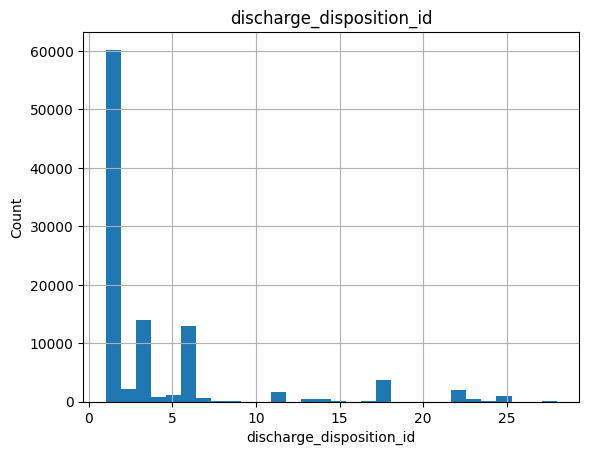

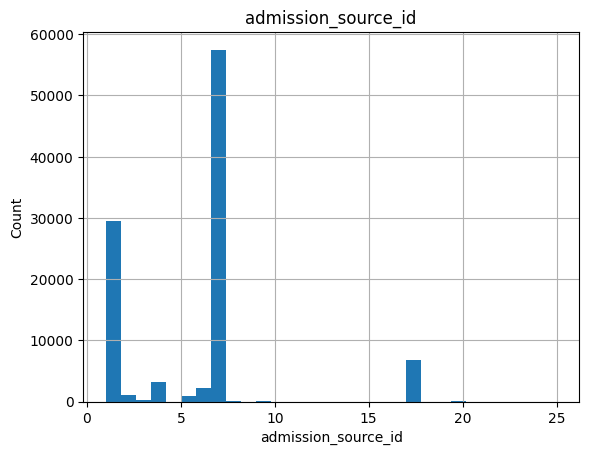

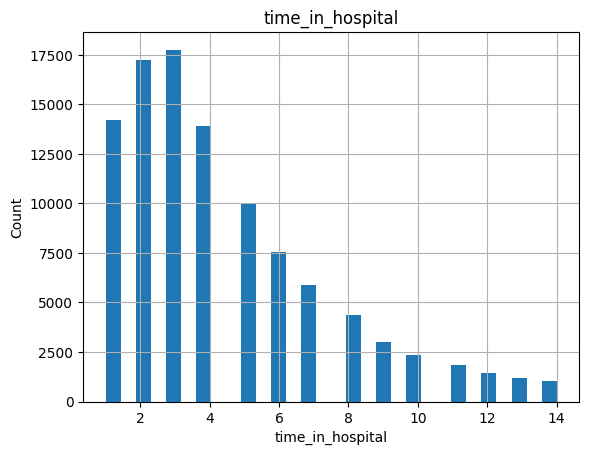

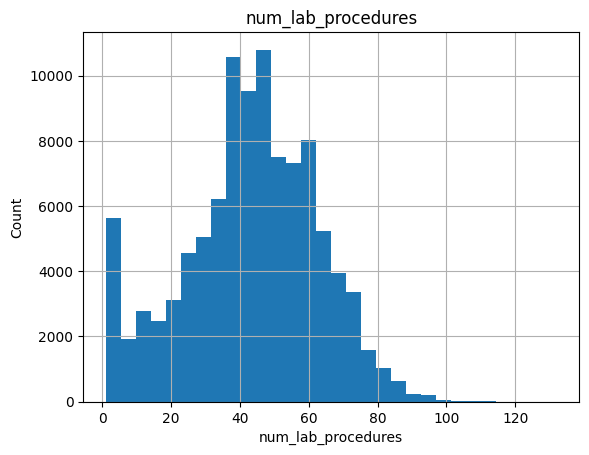

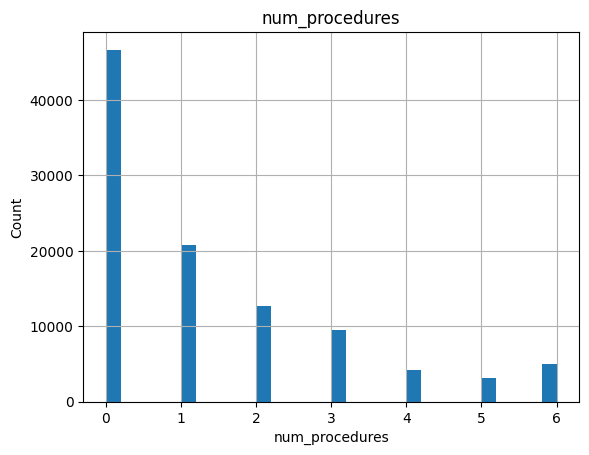

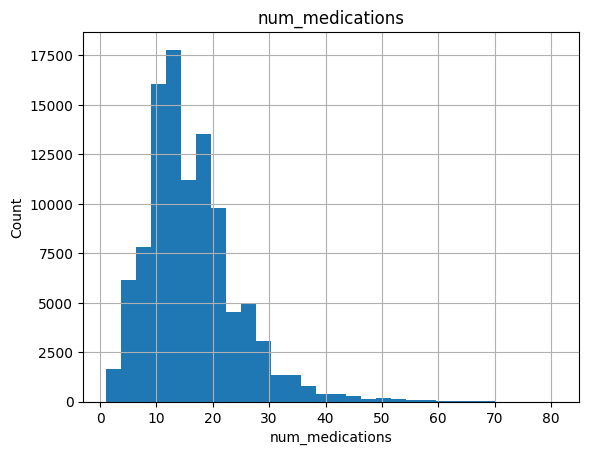

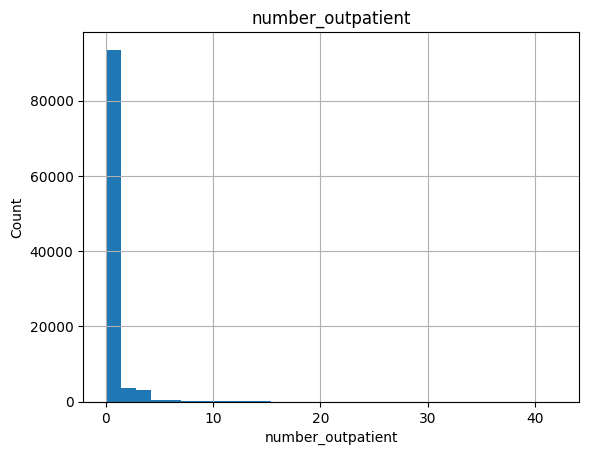

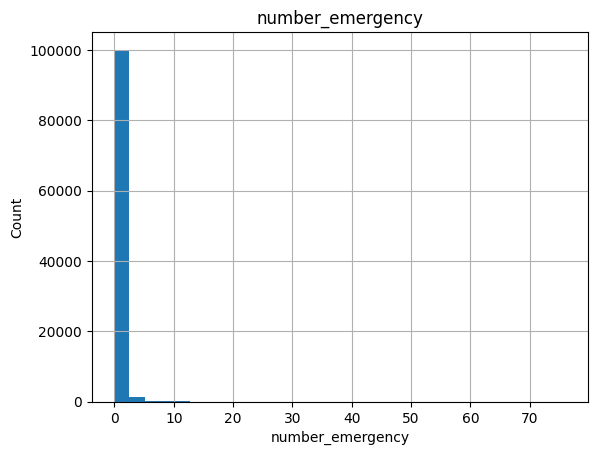

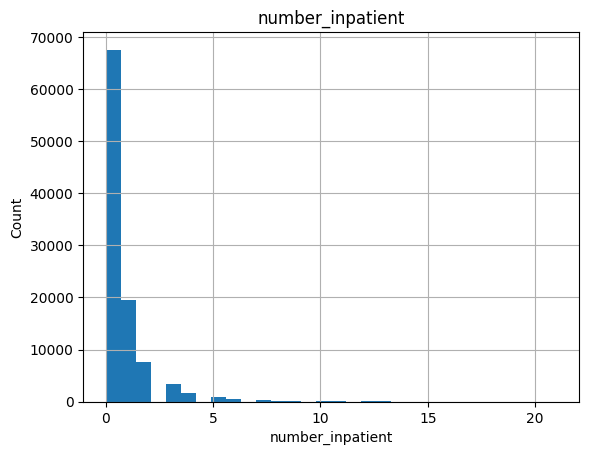

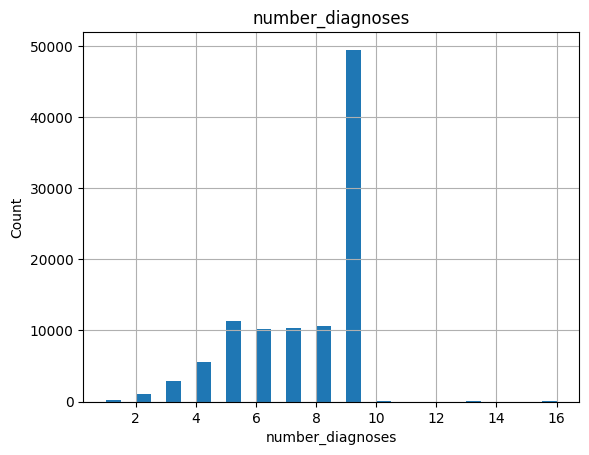

In [6]:
num_cols = df_filtered2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure()
    df_filtered2[col].dropna().hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 6. Categorical Distributions

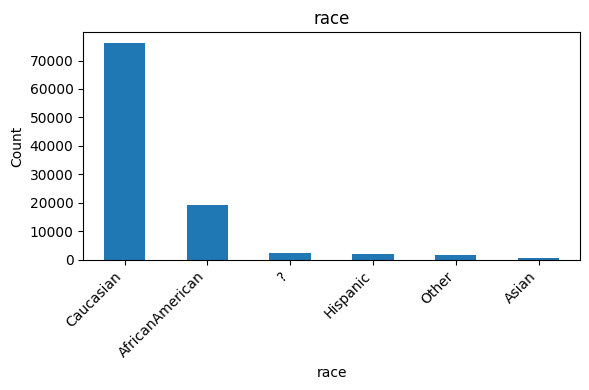

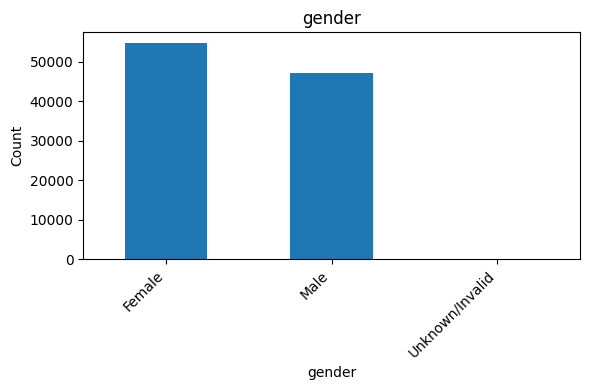

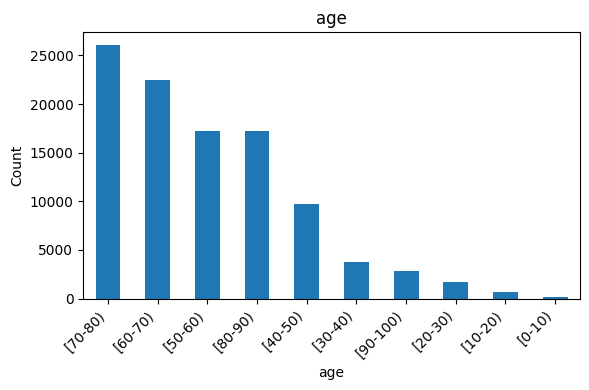

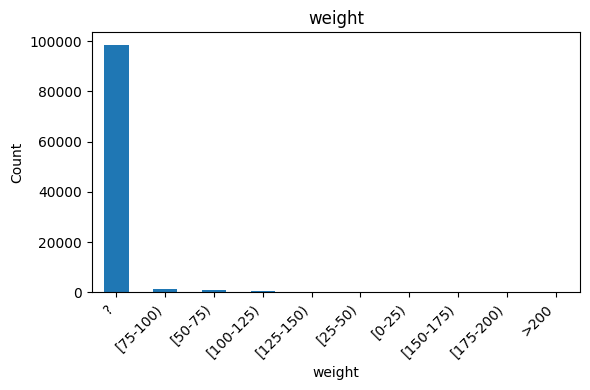

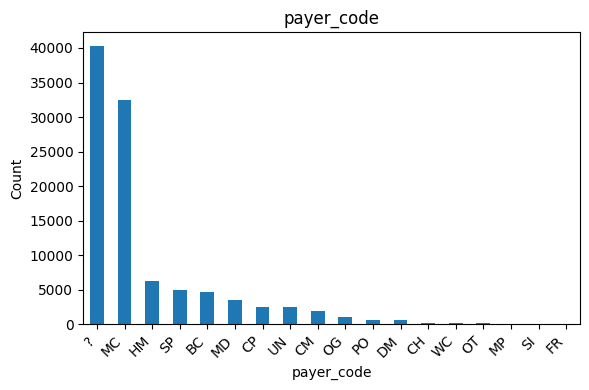

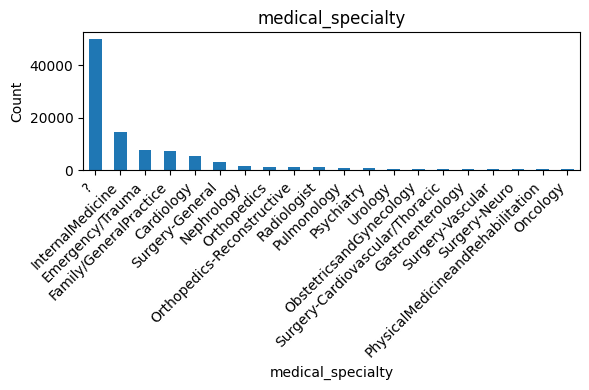

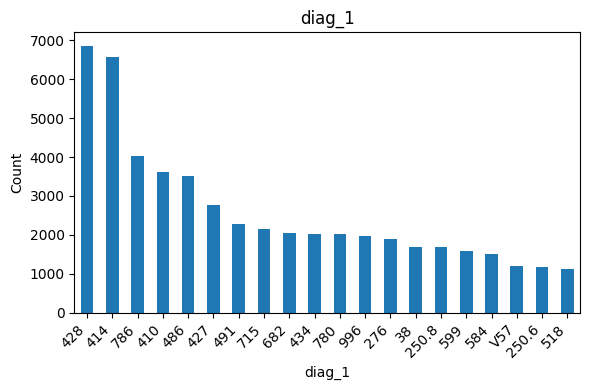

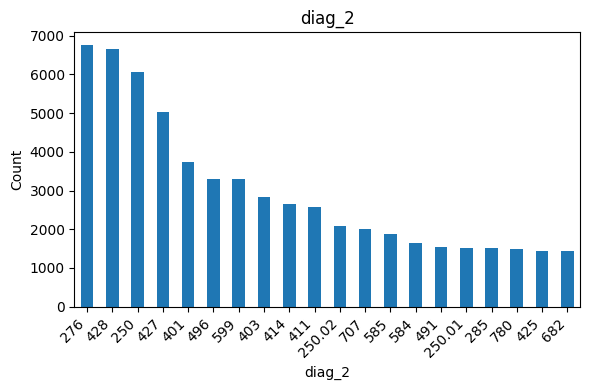

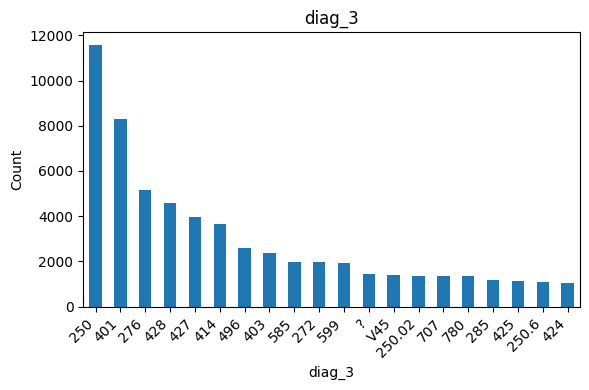

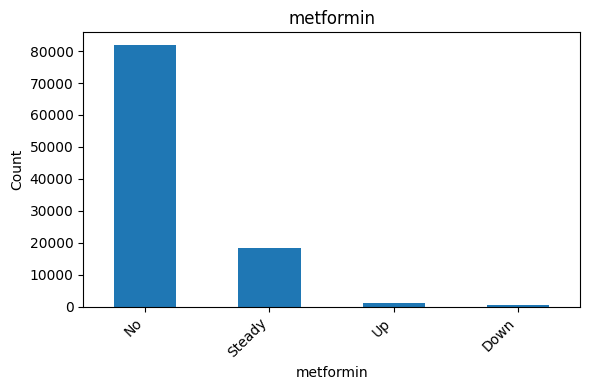

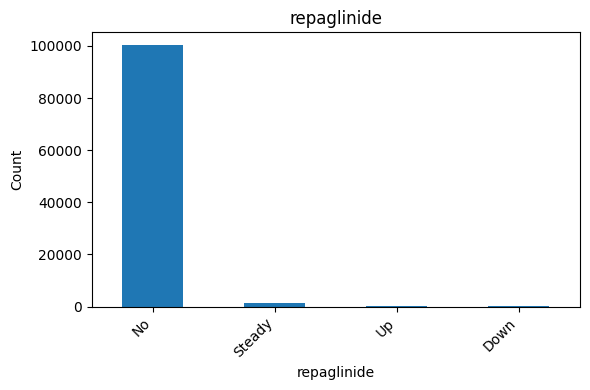

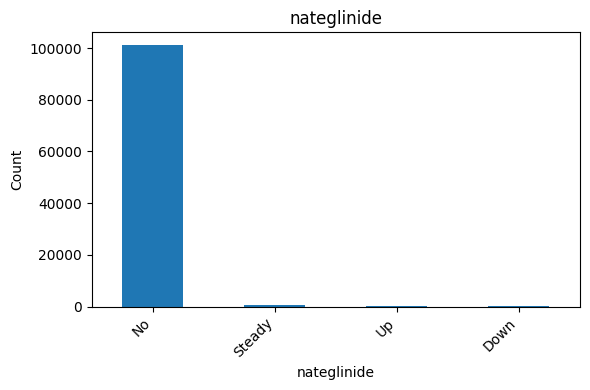

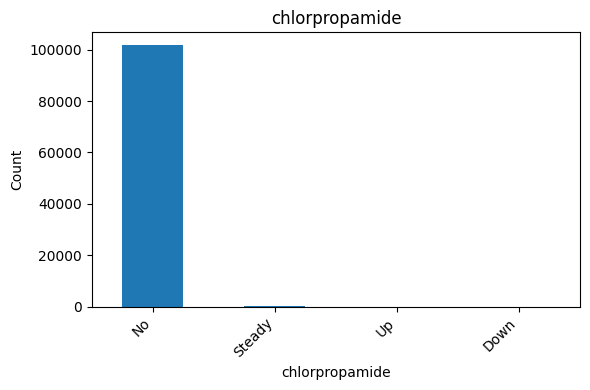

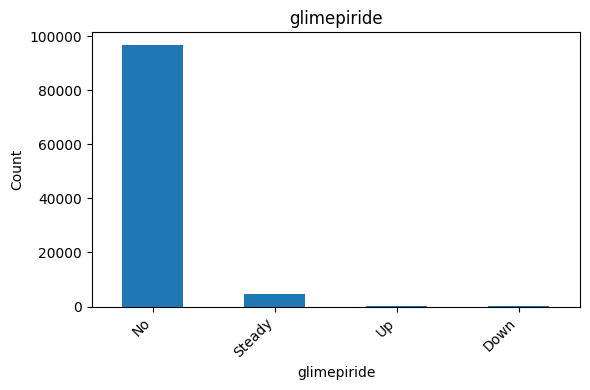

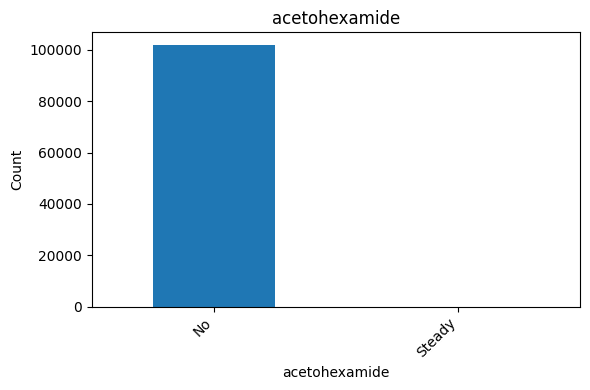

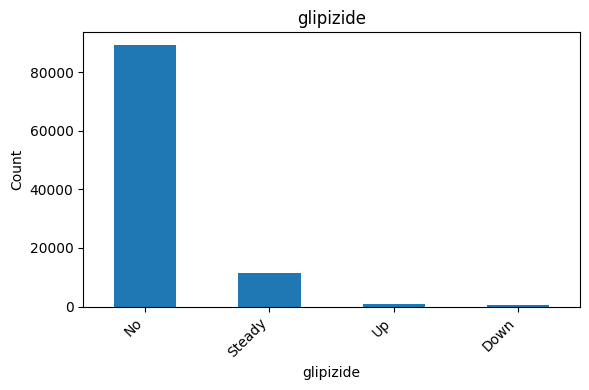

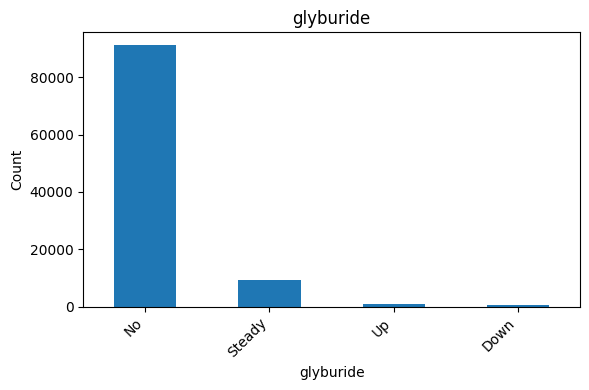

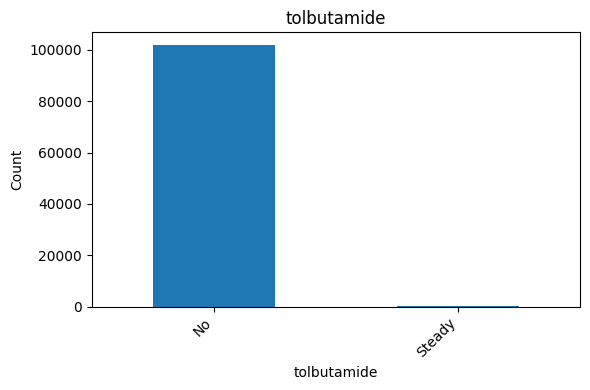

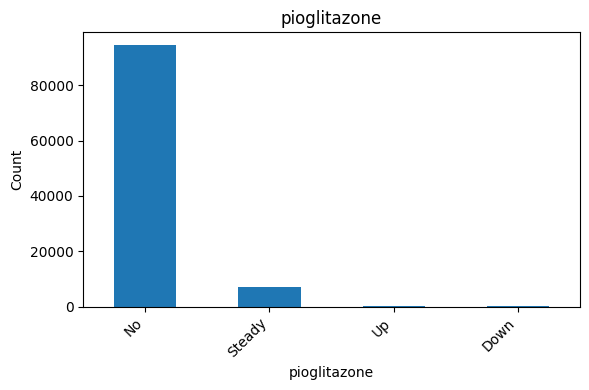

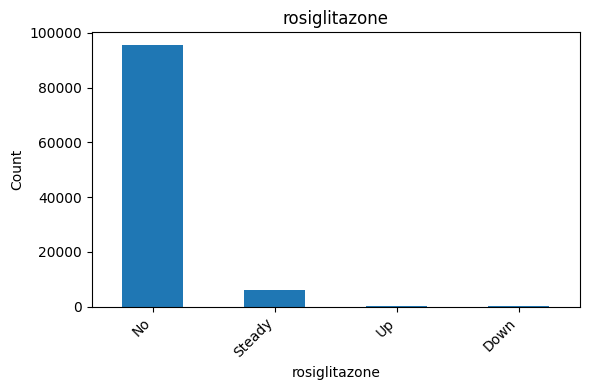

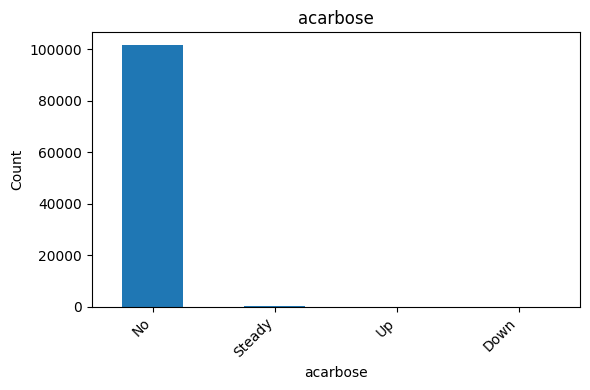

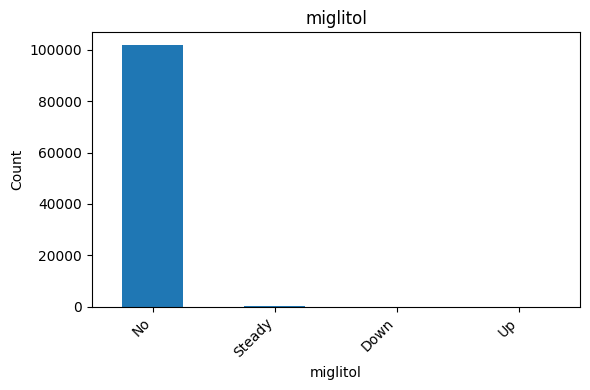

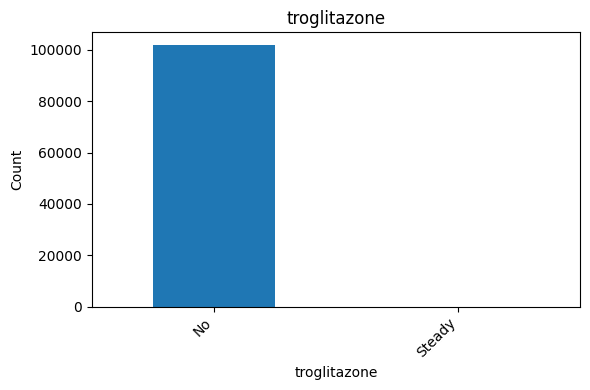

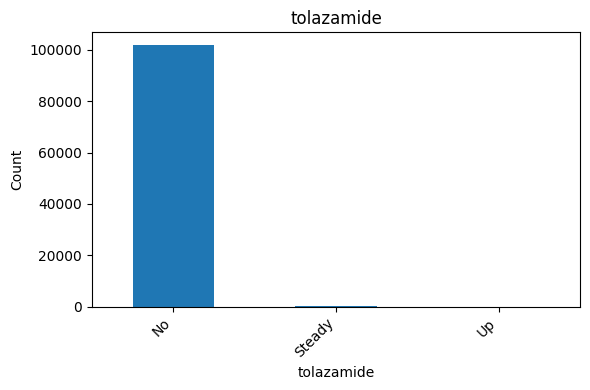

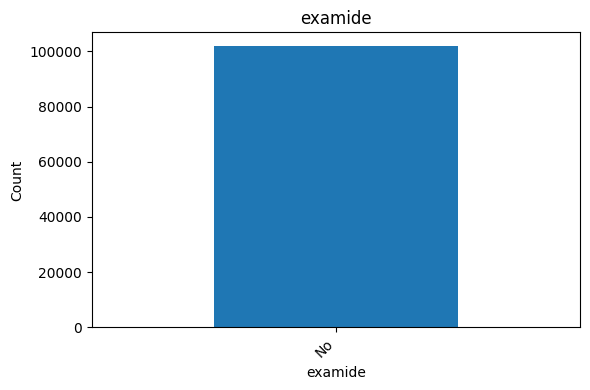

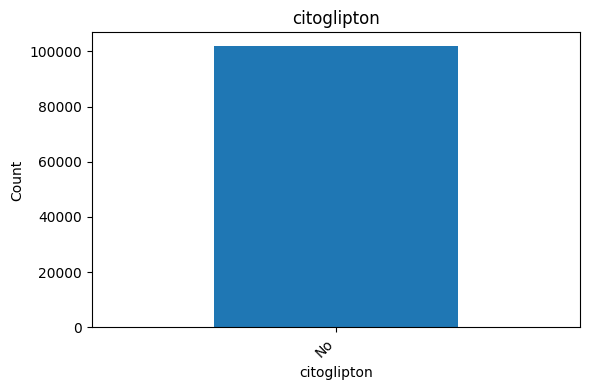

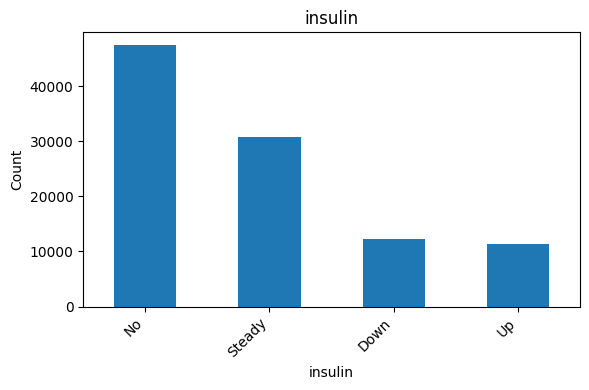

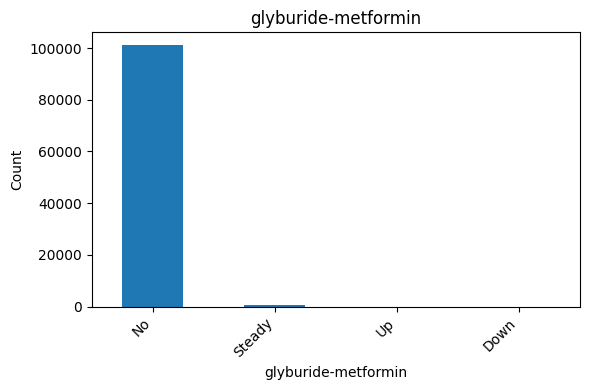

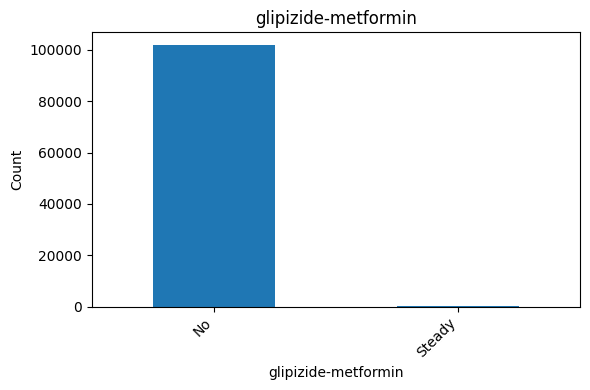

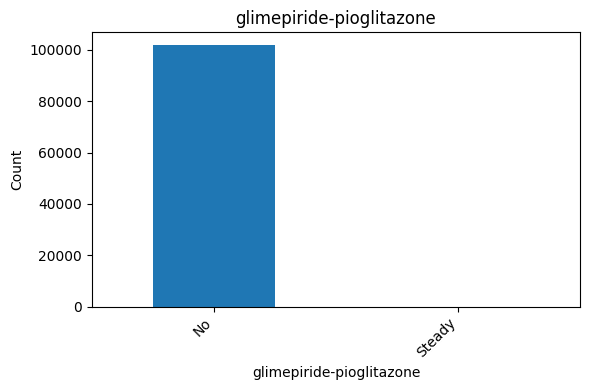

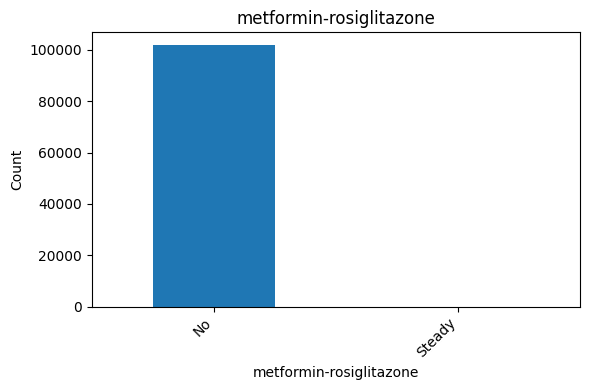

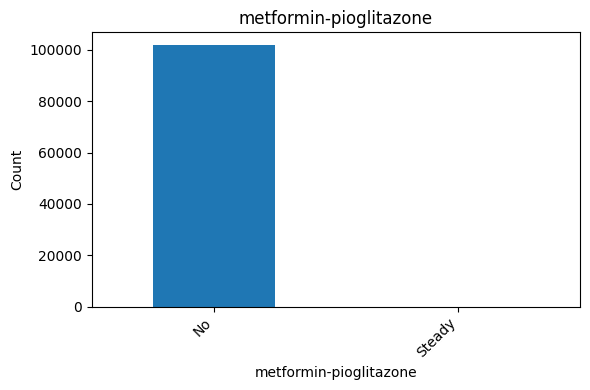

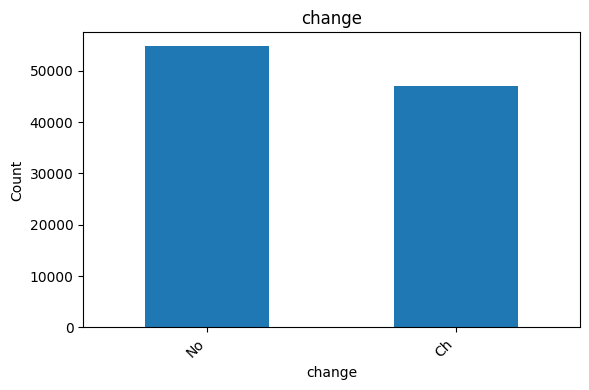

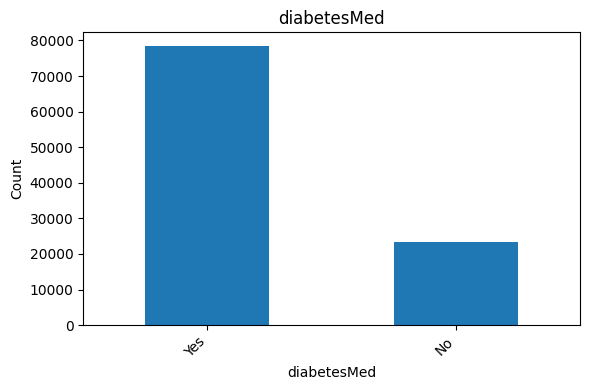

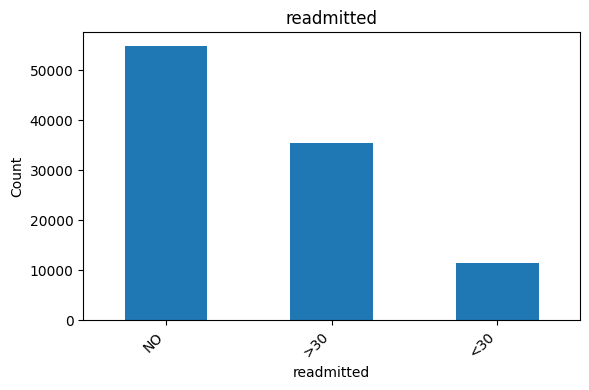

In [7]:
cat_cols = df_filtered2.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df_filtered2[col].value_counts(dropna=False).head(20).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Notes
- Columns with high missingness may need imputation or removal
- Highly skewed distributions may require transformation before GAN training